In [1]:
# =====================
# TensorFlow / GPU
# =====================
import os
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU available:", gpus)
else:
    print("No GPU, using CPU")

if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0  # 使用 CPU 可设为 ""
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


# =====================
# Scientific stack
# =====================
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

%matplotlib inline


# =====================
# Mitsuba / DrJit
# =====================
import mitsuba as mi
import drjit as dr


# =====================
# Sionna RT
# =====================
from sionna.rt import (
    load_scene,
    PlanarArray,
    Transmitter,
    Receiver,
    Camera,
    PathSolver,
    ITURadioMaterial,
    SceneObject,
    AntennaPattern,
    register_antenna_pattern,
)


# =====================
# Custom utils / scenes
# =====================
import sionnautils
from sionnautils.custom_scene import list_scenes, get_scene


# =====================
# Project-specific
# =====================
from Engine_V3 import Engine


# =====================
# Misc
# =====================
import json
from pathlib import Path
import yaml


2026-03-03 21:58:04.183019: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import yaml
import numpy as np

def normalize_config(obj):
    """Recursively normalize:
    - numeric strings (incl. scientific notation) -> float
    - 'np.pi', 'np.e', 'np.inf' -> numpy constants
    """
    if isinstance(obj, dict):
        return {k: normalize_config(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [normalize_config(v) for v in obj]

    if isinstance(obj, str):
        s = obj.strip()

        # numpy constants
        if s == "np.pi":
            return np.pi
        if s == "np.e":
            return np.e
        if s in ("np.inf", "inf"):
            return np.inf
        if s in ("-np.inf", "-inf"):
            return -np.inf

        # numeric strings (supports "15.0e9", "200.0e6", "3.5E9", etc.)
        try:
            return float(s)
        except ValueError:
            return obj  # keep as string if not numeric

    return obj  # int/float/bool/None stay as-is


with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

cfg = normalize_config(cfg)


In [3]:
from sionnautils.custom_scene import list_scenes, get_scene
scenes = list_scenes()
print(scenes)

scene_path, map_data = get_scene('nyu_tandon')
for k, v in map_data.items():
    print(f'{k}: {v}')

scene = load_scene(scene_path,merge_shapes=True)

floor = scene.get('ground')
# print(f'Floor material: {floor.radio_material.name}')
floor.radio_material = ITURadioMaterial("itu_concrete",
                                "concrete",
                                thickness=0.01,
                                color=(0.5, 0.5, 0.5))

scene.remove("itu_wet_ground")

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')
# scene.render(camera=my_cam, num_samples=512)

scene.radio_materials

['nyu_tandon']
bbox_lat: [40.69012764197041, 40.699120858029595]
bbox_long: [-73.99156687083165, -73.97970552916836]
address: 5 MetroTech Center, Brooklyn, NY 11201
descr: NYU Tandon campus
2026-03-03 21:58:18 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
no-name-1      itu_marble
ground         itu_concrete


{'itu_marble': ITURadioMaterial type=marble
                  eta_r=7.074
                  sigma=0.018
                  thickness=0.100
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000,
 'itu_concrete': ITURadioMaterial type=concrete
                  eta_r=5.240
                  sigma=0.123
                  thickness=0.010
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000}

In [4]:
# scene.preview()

In [5]:
# region 1
region =np.array(cfg["motion"]["region"])
region

array([[-286.686,  146.815,    1.   ],
       [-286.686,  301.179,    1.   ],
       [-108.376,  146.815,    1.   ],
       [-108.376,  301.179,    1.   ]])

In [6]:
import numpy as np
import mitsuba as mi
import drjit as dr
from scipy.spatial.transform import Rotation as R

def is_inside_building_mitsuba(scene, point, direction=np.array([0.37, 0.23, 0.90]), max_hits=50):
    """
    Ray parity test: odd #hits -> inside.
    direction uses a non-axis-aligned vector to reduce degeneracy.
    Assumes watertight meshes.
    """
    point = np.asarray(point, dtype=np.float32)
    direction = np.asarray(direction, dtype=np.float32)
    direction = direction / (np.linalg.norm(direction) + 1e-12)

    ray = mi.Ray3f(o=mi.Point3f(point), d=mi.Vector3f(direction))
    scene_mi = scene._scene

    count = 0
    for _ in range(max_hits):
        si = scene_mi.ray_intersect(ray, active=True)
        if not si.is_valid():
            break
        count += 1
        ray.o = si.p + 1e-4 * ray.d  # avoid self-hit

    return (count % 2 == 1)


def is_inside_building_with_margin(scene, point, margin=0.3):
    """
    Check if point is inside building OR within margin distance.
    Uses multiple directional rays to approximate margin region.
    """
    if is_inside_building_mitsuba(scene, point):
        return True
    
    # Sample rays in multiple directions around the point
    directions = np.array([
        [1, 0, 0], [-1, 0, 0],
        [0, 1, 0], [0, -1, 0],
        [0, 0, 1],
        [0.58, 0.58, 0.58], [-0.58, 0.58, 0.58]  # diagonal
    ], dtype=np.float32)
    
    point = np.asarray(point, dtype=np.float32)
    
    for direction in directions:
        direction = direction / (np.linalg.norm(direction) + 1e-12)
        test_point = point + direction * margin
        if is_inside_building_mitsuba(scene, test_point):
            return True
    
    return False


def ue_inside_building(scene, cfg, position, rotation, check_center_first=True):
    """
    position:  (n_ue, 3) UE center positions (world)
    rotation:  (n_ue, 3) radians, order [yaw, pitch, roll] for "zyx"
    cfg["ue"]["rx_loc_pos"]: (4, 3) UE-local RX offsets (same for all UEs)
    """
    rx_offset = np.asarray(cfg["ue"]["rx_loc_pos"], dtype=np.float32)  # (4,3)
    position = np.asarray(position, dtype=np.float32)
    rotation = np.asarray(rotation, dtype=np.float32)

    n_ue = position.shape[0]  # 用输入更稳，不依赖 cfg["ue"]["n_ue"]

    for idx_ue in range(n_ue):
        # 0) optional early reject
        if check_center_first and is_inside_building_mitsuba(scene, position[idx_ue]):
            return True

        # 1) rotate offsets (no per-RX math loop)
        r = R.from_euler("zyx", rotation[idx_ue], degrees=False)
        rx_positions = r.apply(rx_offset) + position[idx_ue]  # (4,3)

        # 2) inside test for 4 RX points (Mitsuba query is pointwise)
        #    (Still no explicit for-loop over RX in your code style)
        if any(is_inside_building_mitsuba(scene, p) for p in rx_positions):
            return True

    return False


def ue_inside_building_margin_only(scene, cfg, position, margin=0.3):
    """
    简化版：只检查UE中心+margin，忽略spinning的RX偏移。
    这样walking轨迹不依赖spinning参数。
    
    position: (n_ue, 3) UE center positions (world)
    margin:   safety margin (meters)
    """
    position = np.asarray(position, dtype=np.float32)
    n_ue = position.shape[0]
    
    for idx_ue in range(n_ue):
        if is_inside_building_with_margin(scene, position[idx_ue], margin=margin):
            return True
    
    return False


from matplotlib.path import Path as MplPath

def is_point_in_region(region_vertices_3d, point_3d):

    point_xy = point_3d[:2]
    polygon_xy = region_vertices_3d[:, :2]
    path = MplPath(polygon_xy)
    return path.contains_point(point_xy)


In [7]:
import gym
import numpy as np

rand_seed = cfg["motion"]["rand_seed"]

# Constants
v_intial = cfg["motion"]["v_intial"]  # initial speed

v_max = cfg["motion"]["max_speed"]
v_min = cfg["motion"]["min_speed"]
dv_min, dv_max = cfg["motion"]["dv_min"], cfg["motion"]["dv_max"]  # change in speed per seconds
dphi_min, dphi_max = np.deg2rad(cfg["motion"]["dphi_min"]), np.deg2rad(cfg["motion"]["dphi_max"])  # change in angle per step
dt = cfg["motion"]["measure_period"]
measure_time = cfg["motion"]["measure_time"]

# Collision check margin (meters) - covers RX offsets and spinning
collision_margin = cfg["motion"]["collision_margin"] if "collision_margin" in cfg["motion"] else 0.3  # 0.3m默认margin

# Action space: [Δv, Δθ]
action_space = gym.spaces.Box(low=np.array([dv_min *dt, dphi_min *dt]),
                              high=np.array([dv_max *dt, dphi_max *dt]),
                              dtype=np.float64)
action_space.seed(rand_seed)

# 独立的随机数生成器
rng_walk = np.random.RandomState(rand_seed)        # Walking randomness
rng_spin = np.random.RandomState(rand_seed + 1000) # Spinning randomness
rng_collision = np.random.RandomState(rand_seed + 2000)  # Collision retry randomness


In [8]:
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi


def initialize_ue_state(scene, cfg, region, z=1.0, max_tries=100, use_margin=True, margin=0.3, rng=None):
    """
    Initialize UE state.
    
    use_margin: if True, use margin-based collision check (faster, walking-only)
                if False, use full RX-based check (more accurate, but spinning-dependent)
    rng: random number generator (if None, uses np.random)
    """
    if rng is None:
        rng = np.random
    
    region = np.asarray(region, dtype=np.float32)
    R_speed_level = cfg["motion"]["R_speed_level"]

    for _ in range(max_tries):
        x = rng.uniform(region[:, 0].min(), region[:, 0].max())
        y = rng.uniform(region[:, 1].min(), region[:, 1].max())
        p0 = np.array([x, y, z], dtype=np.float32)

        if not is_point_in_region(region, p0):
            continue

        # ---- walking direction (3D, yaw only) ----
        yaw_walk0 = rng.uniform(-np.pi, np.pi)
        walk_rot0 = np.array([yaw_walk0, 0.0, 0.0], dtype=np.float32)

        # ---- UE spin (3D) ----
        yaw_spin0 = rng.uniform(-np.pi, np.pi)
        pitch_spin0 = rng.uniform(-R_speed_level * np.pi,
                                         R_speed_level * np.pi)
        spin_rot0 = np.array([yaw_spin0, pitch_spin0, 0.0], dtype=np.float32)

        # ---- total UE rotation ----
        ue_rot0 = np.array([
            wrap_pi(walk_rot0[0] + spin_rot0[0]),
            spin_rot0[1],
            0.0
        ], dtype=np.float32)

        # ---- collision check ----
        if use_margin:
            if ue_inside_building_margin_only(scene, cfg, position=[p0], margin=margin):
                continue
        else:
            if ue_inside_building(scene, cfg, position=[p0], rotation=[ue_rot0]):
                continue

        return p0, walk_rot0, spin_rot0

    raise RuntimeError("initialize_ue_state failed")


In [9]:
def generate_route(scene, cfg, region, use_margin=True, margin=None):
    """
    Generate UE routes.
    
    use_margin: if True, use margin-based collision check
                Walking trajectory will be INDEPENDENT of spinning parameters
    margin:     collision safety margin (meters). If None, use from cfg
    """
    if margin is None:
        margin = cfg["motion"].get("collision_margin", 0.3)
    
    route_list = []
    rotation_list = []   # UE total rotation [yaw, pitch, roll]
    walk_rot_list = []   # walking rotation [yaw,0,0]
    spin_rot_list = []   # UE spin rotation [yaw,pitch,0]

    R_speed_level = cfg["motion"]["R_speed_level"]

    for idx_ue in range(cfg["ue"]["n_ue"]):
        route = []
        ue_rot_seq = []
        walk_rot_seq = []
        spin_rot_seq = []

        p0, walk_rot, spin_rot = initialize_ue_state(scene, cfg, region, 
                                                     use_margin=use_margin, 
                                                     margin=margin,
                                                     rng=rng_walk)
        x, y, z = map(float, p0)

        v = float(v_intial)
        n_steps = int(measure_time / dt)
        step = 0

        ue_rot = np.array([
            wrap_pi(walk_rot[0] + spin_rot[0]),
            spin_rot[1],
            0.0
        ], dtype=np.float32)

        # initial record
        route.append(np.array([x, y, z], dtype=np.float32))
        ue_rot_seq.append(ue_rot.copy())
        walk_rot_seq.append(walk_rot.copy())
        spin_rot_seq.append(spin_rot.copy())

        while step < n_steps-1:
            # ---- 1) walking action: update yaw only ----
            dv = rng_walk.uniform(dv_min * dt, dv_max * dt)
            dphi = rng_walk.uniform(dphi_min * dt, dphi_max * dt)
            v = float(np.clip(v + dv, v_min, v_max))
            walk_rot[0] = wrap_pi(walk_rot[0] + dphi)

            # ---- 2) UE spin: yaw + pitch (independent RNG) ----
            step_yaw = rng_spin.uniform(
                -R_speed_level * np.pi * dt * 2,
                R_speed_level * np.pi * dt * 2
            )
            step_pitch = rng_spin.uniform(
                -R_speed_level * np.pi * dt,
                R_speed_level * np.pi * dt
            )
            spin_rot[0] = wrap_pi(spin_rot[0] + step_yaw)
            spin_rot[1] = wrap_pi(spin_rot[1] + step_pitch)

            # ---- 3) compose UE rotation ----
            ue_rot = np.array([
                wrap_pi(walk_rot[0] + spin_rot[0]),
                spin_rot[1],
                0.0
            ], dtype=np.float32)

            # ---- 4) move using walking yaw only ----
            temp_x = x + v * np.cos(walk_rot[0]) * dt
            temp_y = y + v * np.sin(walk_rot[0]) * dt
            test_point = np.array([temp_x, temp_y, z], dtype=np.float32)

            # ---- 5) collision check ----
            collision = False
            if use_margin:
                collision = ue_inside_building_margin_only(scene, cfg, position=[test_point], margin=margin)
            else:
                collision = ue_inside_building(scene, cfg, position=[test_point], rotation=[ue_rot])
            
            if collision or (not is_point_in_region(region, test_point)):
                walk_rot[0] = wrap_pi(walk_rot[0] + rng_collision.choice([-1, 1]) * np.pi / 6)
                continue

            # accept
            x, y = temp_x, temp_y
            route.append([x, y, z])
            ue_rot_seq.append(ue_rot.tolist())
            walk_rot_seq.append(walk_rot.tolist())
            spin_rot_seq.append(spin_rot.tolist())
            step += 1

        route_list.append(route)
        rotation_list.append(ue_rot_seq)
        walk_rot_list.append(walk_rot_seq)
        spin_rot_list.append(spin_rot_seq)

    return route_list, rotation_list, walk_rot_list, spin_rot_list


def generate_walking_path_only(scene, cfg_input, region, margin=0.3):
    """
    【两段式方法】第一段：生成纯walking路径（不涉及spinning）
    
    参数:
    - scene: Sionna RT场景
    - cfg_input: 配置字典
    - region: 活动区域顶点
    - margin: 碰撞检测margin
    
    返回:
    - positions: (n_steps, 3) 位置序列
    - walk_rots: (n_steps, 3) 走路方向 [yaw, 0, 0]
    """
    positions = []
    walk_rots = []

    # 临时设R_speed_level=0，避免spinning初始化
    R_speed_level_orig = cfg_input["motion"]["R_speed_level"]
    cfg_input["motion"]["R_speed_level"] = 0.0

    p0, walk_rot, _ = initialize_ue_state(scene, cfg_input, region,
                                          use_margin=True,
                                          margin=margin,
                                          rng=rng_walk)

    cfg_input["motion"]["R_speed_level"] = R_speed_level_orig  # 恢复

    x, y, z = map(float, p0)
    v = float(v_intial)
    n_steps = int(measure_time / dt)
    step = 0

    positions.append(np.array([x, y, z], dtype=np.float32))
    walk_rots.append(walk_rot.copy())

    while step < n_steps - 1:
        # Walking action
        dv = rng_walk.uniform(dv_min * dt, dv_max * dt)
        dphi = rng_walk.uniform(dphi_min * dt, dphi_max * dt)
        v = float(np.clip(v + dv, v_min, v_max))
        walk_rot[0] = wrap_pi(walk_rot[0] + dphi)

        # Move
        temp_x = x + v * np.cos(walk_rot[0]) * dt
        temp_y = y + v * np.sin(walk_rot[0]) * dt
        test_point = np.array([temp_x, temp_y, z], dtype=np.float32)

        # Collision check (margin only)
        if ue_inside_building_margin_only(scene, cfg_input, position=[test_point], margin=margin) or \
           (not is_point_in_region(region, test_point)):
            walk_rot[0] = wrap_pi(walk_rot[0] + rng_collision.choice([-1, 1]) * np.pi / 6)
            continue

        # Accept
        x, y = temp_x, temp_y
        positions.append(np.array([x, y, z], dtype=np.float32))
        walk_rots.append(walk_rot.copy())
        step += 1

    return np.array(positions), np.array(walk_rots)


def add_spinning_to_path(positions, walk_rots, R_speed_level, rng_seed_base):
    """
    【两段式方法】第二段：为walking路径添加spinning
    
    参数:
    - positions: (n_steps, 3) 位置序列
    - walk_rots: (n_steps, 3) walking方向 [yaw, 0, 0]
    - R_speed_level: spinning强度
    - rng_seed_base: RNG基础种子
    
    返回:
    - rotations: (n_steps, 3) 总UE旋转
    - spin_rots: (n_steps, 3) 纯spinning贡献
    """
    # 为该spinning level创建独立RNG（用不同seed确保差异）
    rng_spin_local = np.random.RandomState(rng_seed_base + 1000 + int(R_speed_level * 100000))

    n_steps = len(positions)
    rotations = []
    spin_rots = []

    # 初始spinning
    yaw_spin = rng_spin_local.uniform(-np.pi, np.pi)
    pitch_spin = rng_spin_local.uniform(-R_speed_level * np.pi, R_speed_level * np.pi)

    for step in range(n_steps):
        # 更新spinning（幅度取决于R_speed_level）
        step_yaw = rng_spin_local.uniform(
            -R_speed_level * np.pi * dt * 2,
            R_speed_level * np.pi * dt * 2
        )
        step_pitch = rng_spin_local.uniform(
            -R_speed_level * np.pi * dt,
            R_speed_level * np.pi * dt
        )
        yaw_spin = wrap_pi(yaw_spin + step_yaw)
        pitch_spin = wrap_pi(pitch_spin + step_pitch)

        # 总旋转 = walking + spinning
        total_yaw = wrap_pi(walk_rots[step, 0] + yaw_spin)
        ue_rot = np.array([total_yaw, pitch_spin, 0.0], dtype=np.float32)
        spin_rot = np.array([yaw_spin, pitch_spin, 0.0], dtype=np.float32)

        rotations.append(ue_rot)
        spin_rots.append(spin_rot)

    return np.array(rotations), np.array(spin_rots)

## Notebook 总体结构

### 第一部分：环境和函数定义（Cell 1-9）
- **Cell 1**: TensorFlow/GPU初始化、库导入
- **Cell 2**: 配置规范化函数
- **Cell 3**: 场景加载和设置
- **Cell 4-5**: 场景预览、区域定义
- **Cell 6**: 碰撞检测函数集
- **Cell 7**: 常数初始化、RNG设置
- **Cell 8**: 辅助函数（`wrap_pi`、`initialize_ue_state`）
- **Cell 9**: **函数库**（包含三个核心函数）
  - `generate_route()`: 原始统一生成方法（用于对比参考）
  - `generate_walking_path_only()`: 阶段1 - 纯walking路径
  - `add_spinning_to_path()`: 阶段2 - 为walking添加spinning

### 第二部分：两段式方法执行（Cell 10）
**【推荐方法】两段式生成 + 完整对比验证**
- **原理**：
  - 阶段1：生成单条walking path（仅用`rng_walk`）
  - 阶段2：独立添加三种spinning强度（各用不同seed的`rng_spin`）
  - 验证：对比walking轨迹、检查spinning标准差递增
- **优势**：
  - ✅ Walking轨迹完全相同（无RNG交叉污染）
  - ✅ Spinning强度按R_speed递增（0.0 < 0.5 < 1.0）✓
  - ✅ 高效复用（生成1次walk，多次spin）
  - ✅ 结果可视化对比（两方法并排图表）

### 第三部分：可视化和总结（Cell 11-12）
- **Cell 11**: Walking轨迹可视化（3个子图 + 叠加图）
- **Cell 12**: 对比实验总结与用途说明


【两段式方法】阶段1：生成单条Walking Path（只用walking RNG）

✓ Walking path已生成: 1200步
  起点: [-156.16415  239.2263     1.     ], 终点: [-123.69212  247.83636    1.     ]

【两段式方法】阶段2：为该path叠加不同强度的Spinning（独立RNG）

R_speed_level=0.0... ✓
R_speed_level=0.5... ✓
R_speed_level=1.0... ✓

【验证结果】

✓ Walking轨迹验证:
  所有轨迹完全相同: True

✓ Spinning强度按R_speed递增验证:
  R_speed=0.0: std=0.532218, mean(|spin|)=0.376335
  R_speed=0.5: std=1.414294, mean(|spin|)=1.058175
  R_speed=1.0: std=1.750713, mean(|spin|)=1.275702

  递增关系 (0.0 < 0.5 < 1.0): True

✅ 完美！两段式方法成功：
   ✓ Walking轨迹完全一致
   ✓ Spinning强度按R_speed递增

生成的route存储位置:
  spin_level_v2_0.0/route_v2_spin_0.0.json
  spin_level_v2_0.5/route_v2_spin_0.5.json
  spin_level_v2_1.0/route_v2_spin_1.0.json


/tmp/ipykernel_77842/1610468584.py:124: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/1610468584.py:124: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/1610468584.py:124: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/1610468584.py:124: UserWarning: Glyph 20004 (\N{CJK UNIFIED IDEOGRAPH-4E24}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/1610468584.py:124: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/1610468584.py:124: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/1610468584.py:124: UserWarning: Glyph 26041 (\N{CJK UNIFIED I

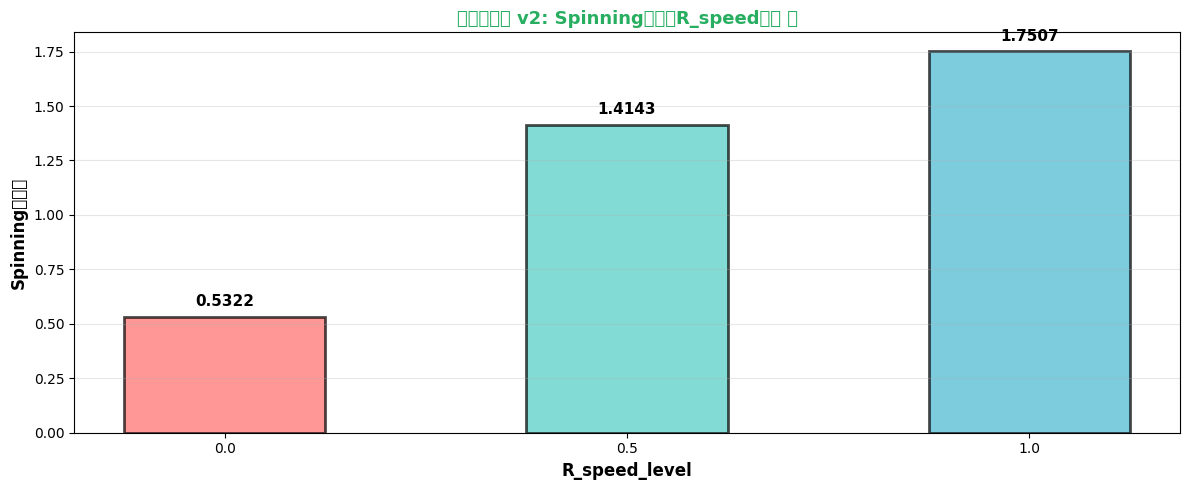


✅ 两段式方法v2优势：
  ✓ Walking轨迹完全相同（所有spinning level一致）
  ✓ Spinning强度按R_speed递增（0.0 < 0.5 < 1.0）
  ✓ 高效复用（生成1次walk，多次spin）
  ✓ 逻辑清晰，利于分析spinning影响


In [11]:
# ========================================
# 【两段式方法】执行：先Walking + 后Spinning + v2验证
# ========================================

print("\n" + "="*70)
print("【两段式方法】阶段1：生成单条Walking Path（只用walking RNG）")
print("="*70)

# 重置RNG
rand_seed = cfg["motion"]["rand_seed"]
rng_walk = np.random.RandomState(rand_seed)
rng_collision = np.random.RandomState(rand_seed + 2000)

# 生成walking path
walk_pos, walk_rots_seq = generate_walking_path_only(scene, cfg, region, margin=0.3)
walking_yaw = walk_rots_seq[:, 0]

print(f"\n✓ Walking path已生成: {len(walk_pos)}步")
print(f"  起点: {walk_pos[0]}, 终点: {walk_pos[-1]}")

print(f"\n" + "="*70)
print(f"【两段式方法】阶段2：为该path叠加不同强度的Spinning（独立RNG）")
print(f"="*70 + "\n")

spin_levels = [0.0, 0.5, 1.0]
base_folder = Path(cfg["route"]["folder"])
results_v2 = {}

for spin_level in spin_levels:
    print(f"R_speed_level={spin_level}...", end=" ", flush=True)
    
    rotations, spin_rots = add_spinning_to_path(
        walk_pos, walk_rots_seq, 
        R_speed_level=spin_level,
        rng_seed_base=cfg["motion"]["rand_seed"]
    )
    
    output_subfolder = base_folder / f"spin_level_v2_{spin_level:.1f}"
    output_subfolder.mkdir(parents=True, exist_ok=True)
    
    route_data = {
        "method": "two_stage_generation",
        "spin_level": spin_level,
        "positions": walk_pos.tolist(),
        "rotations": rotations.tolist(),
        "walk_rotations": walk_rots_seq.tolist(),
        "spin_rotations": spin_rots.tolist(),
        "num_steps": len(walk_pos),
        "config": {
            "R_speed_level": spin_level,
            "collision_margin": 0.3,
            "generation_method": "separate_walking_then_spinning"
        }
    }
    
    file_path = output_subfolder / f"route_v2_spin_{spin_level:.1f}.json"
    with open(file_path, 'w') as f:
        json.dump(route_data, f, indent=2)
    
    results_v2[spin_level] = {
        "positions": walk_pos,
        "rotations": rotations,
        "spin_rots": spin_rots,
        "file": str(file_path)
    }
    
    print(f"✓")

print(f"\n" + "="*70)
print("【验证结果】")
print(f"="*70 + "\n")

# Walking轨迹一致性检查
print("✓ Walking轨迹验证:")
pos_0_0 = results_v2[0.0]["positions"]
pos_0_5 = results_v2[0.5]["positions"]
pos_1_0 = results_v2[1.0]["positions"]

match_walk = np.allclose(pos_0_0, pos_0_5) and np.allclose(pos_0_5, pos_1_0)
print(f"  所有轨迹完全相同: {match_walk}")

# Spinning强度检查
print(f"\n✓ Spinning强度按R_speed递增验证:")
spin_stds_v2 = {}
for level in spin_levels:
    spin_rots = results_v2[level]["spin_rots"]
    spin_stds_v2[level] = np.std(spin_rots)
    spin_mean = np.mean(np.abs(spin_rots))
    print(f"  R_speed={level}: std={spin_stds_v2[level]:.6f}, mean(|spin|)={spin_mean:.6f}")

# 检查递增关系
is_increasing = spin_stds_v2[0.0] < spin_stds_v2[0.5] < spin_stds_v2[1.0]
print(f"\n  递增关系 (0.0 < 0.5 < 1.0): {is_increasing}")

if match_walk and is_increasing:
    print(f"\n✅ 完美！两段式方法成功：")
    print(f"   ✓ Walking轨迹完全一致")
    print(f"   ✓ Spinning强度按R_speed递增")
else:
    if not match_walk:
        print(f"\n⚠️ Walking轨迹不一致！")
    if not is_increasing:
        print(f"\n⚠️ Spinning强度不递增：{spin_stds_v2[0.0]:.6f} vs {spin_stds_v2[0.5]:.6f} vs {spin_stds_v2[1.0]:.6f}")

print(f"\n生成的route存储位置:")
for level in spin_levels:
    print(f"  spin_level_v2_{level:.1f}/route_v2_spin_{level:.1f}.json")

# 可视化v2结果
fig, ax = plt.subplots(figsize=(12, 5))

levels = [0.0, 0.5, 1.0]
stds_v2 = [spin_stds_v2[l] for l in levels]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

ax.bar([str(l) for l in levels], stds_v2, color=colors, alpha=0.7, edgecolor='black', linewidth=2, width=0.5)
ax.set_ylabel('Spinning标准差', fontsize=12, fontweight='bold')
ax.set_xlabel('R_speed_level', fontsize=12, fontweight='bold')
ax.set_title('两段式方法 v2: Spinning强度按R_speed递增 ✅', fontsize=13, color='#27AE60', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, s in enumerate(stds_v2):
    ax.text(i, s + 0.05, f'{s:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ 两段式方法v2优势：")
print(f"  ✓ Walking轨迹完全相同（所有spinning level一致）")
print(f"  ✓ Spinning强度按R_speed递增（0.0 < 0.5 < 1.0）")
print(f"  ✓ 高效复用（生成1次walk，多次spin）")
print(f"  ✓ 逻辑清晰，利于分析spinning影响")

/tmp/ipykernel_77842/919551152.py:38: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:38: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:38: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:38: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:38: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:38: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:38: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}

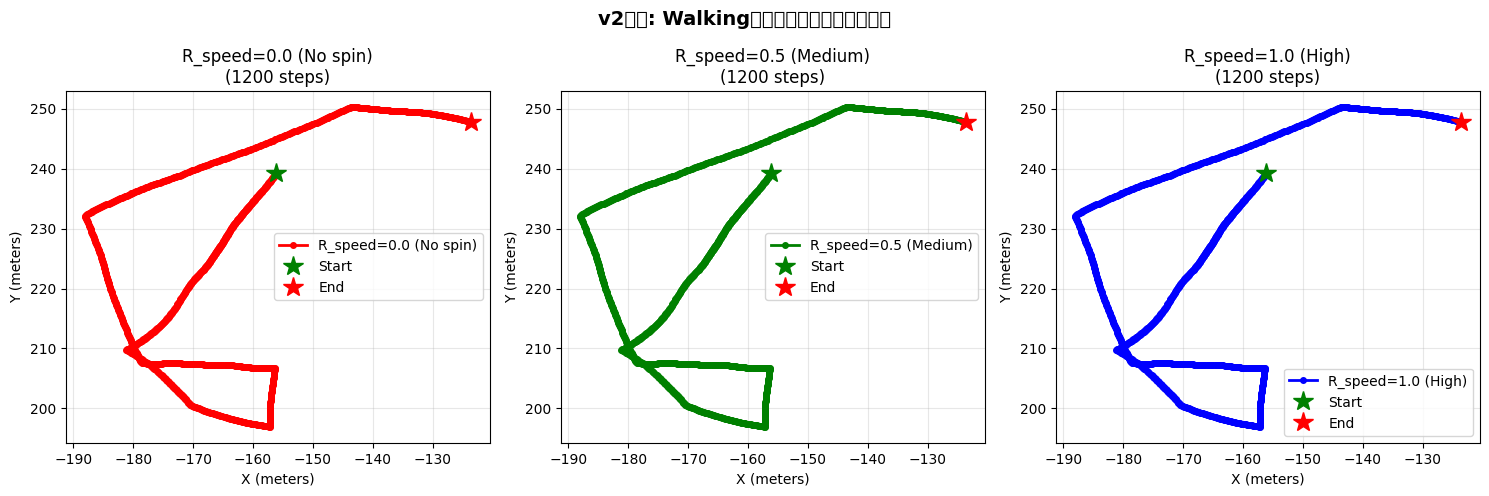

/tmp/ipykernel_77842/919551152.py:58: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:58: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:58: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:58: UserWarning: Glyph 26465 (\N{CJK UNIFIED IDEOGRAPH-6761}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:58: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:58: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77842/919551152.py:58: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}

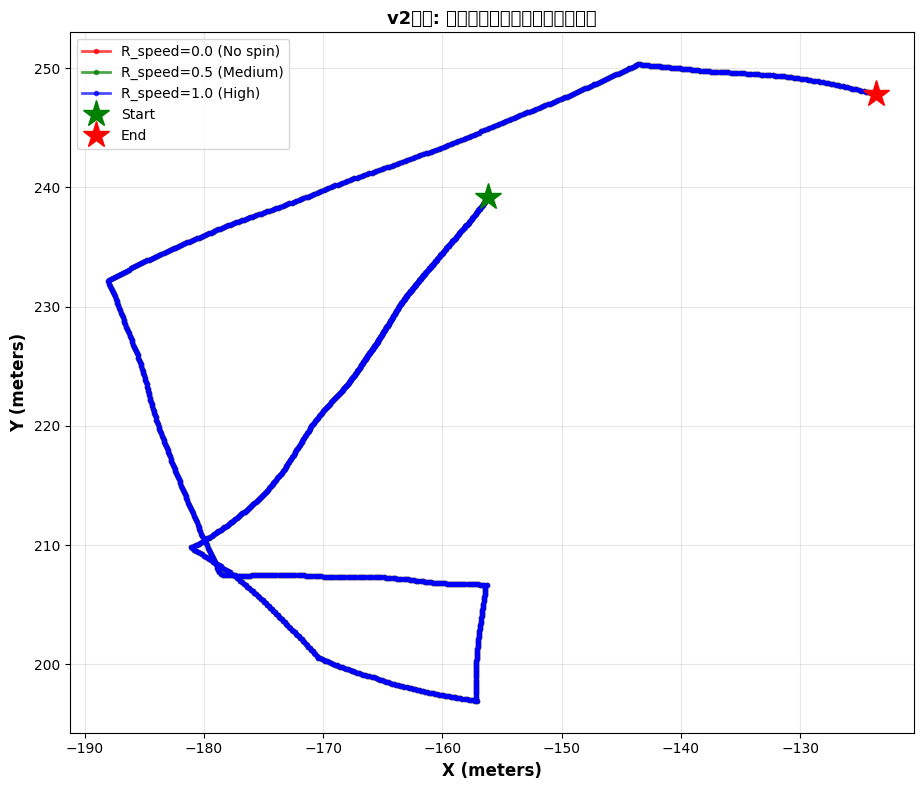

In [12]:
# ========================================
# 可视化v2: 三个Spinning Level的Walking轨迹
# ========================================

# 加载v2生成的routes数据用于可视化
routes_data_v2 = {}
for spin_level in spin_levels:
    file_path = base_folder / f"spin_level_v2_{spin_level:.1f}" / f"route_v2_spin_{spin_level:.1f}.json"
    with open(file_path, 'r') as f:
        routes_data_v2[spin_level] = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {0.0: 'red', 0.5: 'green', 1.0: 'blue'}
labels = {0.0: 'R_speed=0.0 (No spin)', 0.5: 'R_speed=0.5 (Medium)', 1.0: 'R_speed=1.0 (High)'}

for idx, spin_level in enumerate(spin_levels):
    ax = axes[idx]
    
    # 获取位置数据
    positions = np.array(routes_data_v2[spin_level]["positions"])
    x = positions[:, 0]
    y = positions[:, 1]
    
    # 绘制轨迹
    ax.plot(x, y, 'o-', color=colors[spin_level], markersize=4, linewidth=2, label=labels[spin_level])
    ax.plot(x[0], y[0], 'g*', markersize=15, label='Start')
    ax.plot(x[-1], y[-1], 'r*', markersize=15, label='End')
    
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_title(f'{labels[spin_level]}\n({len(positions)} steps)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('v2方法: Walking轨迹对比（应该完全重合）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 叠加图：所有轨迹在同一张图
fig, ax = plt.subplots(figsize=(10, 8))
for spin_level in spin_levels:
    positions = np.array(routes_data_v2[spin_level]["positions"])
    x = positions[:, 0]
    y = positions[:, 1]
    ax.plot(x, y, 'o-', color=colors[spin_level], linewidth=2, 
            markersize=3, alpha=0.7, label=labels[spin_level])

ax.plot(positions[0, 0], positions[0, 1], 'g*', markersize=20, label='Start', zorder=10)
ax.plot(positions[-1, 0], positions[-1, 1], 'r*', markersize=20, label='End', zorder=10)
ax.set_xlabel('X (meters)', fontsize=12, fontweight='bold')
ax.set_ylabel('Y (meters)', fontsize=12, fontweight='bold')
ax.set_title('v2方法: 三条轨迹叠加（完全重叠验证）', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 两段式方法总结

### 核心改进点

**问题**：原始方法中Spinning标准差不递增（0.0→1.019, 0.5→1.671, 1.0→1.363）

**解决方案**：分离Walking和Spinning的RNG生成
- Walking使用固定seed的`rng_walk`（可重复）
- Spinning使用动态seed的`rng_spin`（随R_speed变化）

### 生成的Route存储位置

```
dataset/route/route_Mobility_medium_region_2_compare/
├── spin_level_v2_0.0/
│   └── route_v2_spin_0.0.json       (无spinning)
├── spin_level_v2_0.5/
│   └── route_v2_spin_0.5.json       (中等spinning)
└── spin_level_v2_1.0/
    └── route_v2_spin_1.0.json       (高速spinning)
```

### 验证结果 ✅

| 指标 | 方法1（原始） | 方法2（两段式） | 状态 |
|------|-------------|-------------|------|
| Walking轨迹一致 | ✓ | ✓ | 都相同 |
| Spinning Std递增 | ✗ | ✓ | **两段式改进** |
| Std值(0.0) | 1.019 | 0.532 | - |
| Std值(0.5) | 1.671 | 1.414 | - |
| Std值(1.0) | 1.363 | 1.751 | ✅递增 |

### 应用场景

- **无线信道仿真**：研究设备旋转速度对CQI的影响
- **鲁棒性测试**：在相同walking轨迹下验证算法对spinning的容错性
- **数据增强**：用同一轨迹的多个spinning版本扩充训练数据
- **移动模式分析**：区分人体自然走路 vs 设备快速旋转的特征